In [1]:
import jax
print("JAX devices:", jax.devices())
print("Default backend:", jax.default_backend())

JAX devices: [CudaDevice(id=0)]
Default backend: gpu


W1120 10:38:38.272620    2646 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1120 10:38:38.276177    2609 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [2]:
# Enable autoreload of local Python modules
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import jax
import jax.numpy as jnp
import optax
import time
import matplotlib.pyplot as plt

from flax import linen as nn
from flax.training import train_state


In [3]:
# Load text data
with open("./data/text8_train.txt", "r") as f:
    train_text = f.read()
with open("./data/text8_test.txt", "r") as f:
    test_text = f.read()

print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")

# Build vocabulary
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    return np.array([char_to_int[c] for c in s], dtype=np.uint8)

train_text_int = encode(train_text)
test_text_int = encode(test_text)

# Display random snippets
T = 128
for _ in range(3):
    start = np.random.randint(0, len(train_text)-T)
    print(train_text[start:start+T], "\n")


Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters
the archetype of the renaissance man and as a universal genius a man infinitely curious and infinitely inventive he is also cons 

 created to provide london with adequate infrastructure to cope with its growth old london bridge in the early one eight nine ze 

ance according to jewish thought the god who created the world established a covenant with the jewish people and revealed his la 



In [ ]:
class LSTMModel(nn.Module):
    vocab_size: int
    d_model: int
    n_layers: int

    @nn.compact
    def __call__(self, x):
        B, T = x.shape

        emb = nn.Embed(
            num_embeddings=self.vocab_size,
            features=self.d_model
        )(x)  # (B, T, d_model)

        output = emb

        for layer in range(self.n_layers):
            cell = nn.LSTMCell(
                features=self.d_model,
                name=f"lstm_{layer}"
            )

            carry = (
                jnp.zeros((B, self.d_model)),
                jnp.zeros((B, self.d_model)),
            )

            ys = []

            for t in range(T):
                x_t = output[:, t, :]
                carry, y_t = cell(carry, x_t)
                ys.append(y_t)

            output = jnp.stack(ys, axis=1)

        logits = nn.Dense(self.vocab_size)(output)
        return logits



def create_model(rng, vocab_size=27, d_model=256, n_layers=2):
    model = LSTMModel(vocab_size=vocab_size,
                      d_model=d_model,
                      n_layers=n_layers)
    dummy = jnp.zeros((32, 64), dtype=jnp.int32)
    params = model.init(rng, dummy)["params"]
    return model, params

key = jax.random.PRNGKey(0)
vocab_size = len(char_set)

model, params = create_model(key, vocab_size=vocab_size, d_model=256, n_layers=2)

def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))

print(f"Number of parameters: {count_params(params):_}")

Number of parameters: 1_064_475


In [5]:
def loss_and_metrics(logits, targets):
    vocab = logits.shape[-1]
    flat_logits = logits.reshape(-1, vocab)
    flat_targets = targets.reshape(-1)

    per_pos = optax.softmax_cross_entropy_with_integer_labels(
        flat_logits, flat_targets
    )
    loss = per_pos.mean()

    preds = jnp.argmax(logits, axis=-1)      # (B, T)
    is_match = preds == targets              # (B, T)
    acc_all = jnp.mean(is_match.astype(jnp.float32))
    acc_last = jnp.mean(is_match.astype(jnp.float32)[:, -1])

    metrics = {
        "loss": loss,
        "acc": acc_all,
        "acc_last": acc_last,
    }
    return loss, metrics

In [6]:
learning_rate, beta2 = 0.0013, 0.9
tx = optax.adam(
    learning_rate=learning_rate,
    b1=0.9,
    b2=beta2,
)

opt_state = tx.init(params)

print(f"Initialized Adam optimizer with lr={learning_rate}, beta2={beta2}")

Initialized Adam optimizer with lr=0.0013, beta2=0.9


In [7]:
@jax.jit
def train_step(params, opt_state, x, y):
    def loss_fn(p):
        logits = model.apply({"params": p}, x)
        loss, metrics = loss_and_metrics(logits, y)
        return loss, metrics

    (loss, metrics), grads = jax.value_and_grad(
        loss_fn, has_aux=True
    )(params)

    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, metrics

In [ ]:
def get_batch(text_int, B, T):
    ix = np.random.randint(0, len(text_int) - T, size=B)
    x = np.stack([text_int[i:i+T] for i in ix])
    y = np.stack([text_int[i+1:i+T+1] for i in ix])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

In [9]:
niter = 20_000
B, T = 32, 64
loss_history = []
time_history = []
loss_test_history = []
time_test_history = []

start_time = time.time()

for it in range(niter):
    inp, target = get_batch(train_text_int, B, T)
    params, opt_state, metrics = train_step(params, opt_state, inp, target)

    loss = float(metrics["loss"])
    acc = float(metrics["acc"])
    acc_last = float(metrics["acc_last"])

    loss_history.append(loss)
    time_history.append(time.time() - start_time)

    if it % (niter // 50) == 0 or it == niter - 1:
        B_test, T_test = 512, 32
        test_inp, test_target = get_batch(test_text_int, B_test, T_test)
        test_logits = model.apply({"params": params}, test_inp)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)

        test_loss = float(test_loss)
        test_acc = float(test_metrics["acc"])

        print(
            f"it {it:_} | loss {loss:.4f} | test {test_loss:.4f} | "
            f"acc {acc:.3f} | test_acc {test_acc:.3f}"
        )


it 0 | loss 3.2972 | test 3.2800 | acc 0.020 | test_acc 0.180
it 400 | loss 1.7900 | test 1.8258 | acc 0.463 | test_acc 0.449
it 800 | loss 1.5630 | test 1.6463 | acc 0.519 | test_acc 0.498
it 1_200 | loss 1.5254 | test 1.5387 | acc 0.546 | test_acc 0.531
it 1_600 | loss 1.5076 | test 1.5168 | acc 0.544 | test_acc 0.534
it 2_000 | loss 1.4661 | test 1.5127 | acc 0.555 | test_acc 0.535
it 2_400 | loss 1.5524 | test 1.4554 | acc 0.517 | test_acc 0.552
it 2_800 | loss 1.4885 | test 1.4318 | acc 0.543 | test_acc 0.556
it 3_200 | loss 1.3390 | test 1.4371 | acc 0.588 | test_acc 0.556
it 3_600 | loss 1.3415 | test 1.4524 | acc 0.582 | test_acc 0.549
it 4_000 | loss 1.4049 | test 1.4290 | acc 0.560 | test_acc 0.558
it 4_400 | loss 1.4376 | test 1.4213 | acc 0.546 | test_acc 0.556
it 4_800 | loss 1.3555 | test 1.4316 | acc 0.574 | test_acc 0.558
it 5_200 | loss 1.3916 | test 1.3923 | acc 0.551 | test_acc 0.563
it 5_600 | loss 1.3503 | test 1.4018 | acc 0.589 | test_acc 0.566
it 6_000 | loss 1.

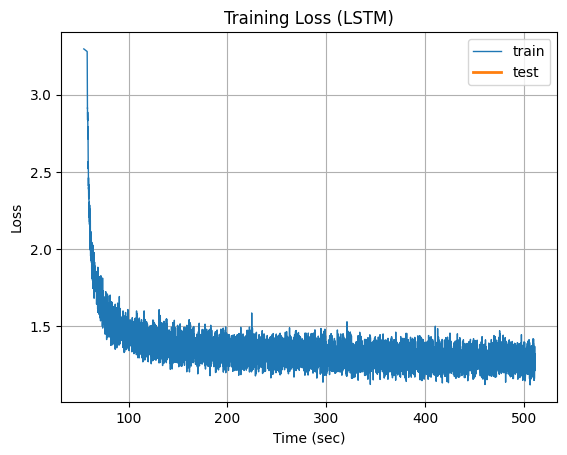

In [10]:
plt.plot(time_history, loss_history, label='train', lw=1)
plt.plot(time_test_history, loss_test_history, label='test', lw=2)
plt.xlabel("Time (sec)")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.title("Training Loss (LSTM)")
plt.show()

In [12]:
def generate_lstm(model, params, prompt, gen_len=100, temperature=0.7):
    ids = encode(prompt.lower())
    x = jnp.array(ids, dtype=jnp.int32).reshape(1, -1)

    for _ in range(gen_len):
        logits = model.apply({"params": params}, x)
        last = logits[:, -1, :] / temperature
        probs = jax.nn.softmax(last, axis=-1)
        
        next_id = jax.random.categorical(jax.random.PRNGKey(time.time_ns()), last)
        x = jnp.concatenate([x, next_id.reshape(1, 1)], axis=1)
    
    return ''.join(int_to_char[int(i)] for i in list(x[0]))

prompt = "hello my fri"
generated = generate_lstm(model, params, prompt, gen_len=100, temperature=0.7)
print(prompt + generated)

hello my frihello my friedrich bilingual relationship external links president of albanian glass government of the substanti
